In [1]:
import os
import sys

import torch
from ultralytics import RTDETR
import pandas as pd
import glob
import numpy as np
from pathlib import Path


# Add project root to system path (for relative imports to work)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src import config
from src.types.types import ModelType


print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.8.0+cu128
CUDA available: False


In [ ]:
def get_test_files_path():

    test_images = config.YOLO_TEST_FORMAT_DIR
    test_files = glob.glob(os.path.join(test_images, "*.jpg"))
    print(f"Found {len(test_files)} test files.")
    return test_files


def get_tomo_id_and_slice_id_from_image_path(image_path: str):
    stem = Path(image_path).stem
    parts = stem.split("_slice_")
    tomo_id = parts[0]  # "tomo_675583"
    slice_id = int(parts[1])  # "0187" # -> tomo_675583_slice_0187
    return tomo_id, slice_id

In [2]:
rtdetr_weights_path = "/data/horse/ws/kein254g-team_project/rtdetr_training_result/exp2/motor_rtdetr_x_102410/weights/best.pt"
rtdetr_results_path = (
    "/home/kein254g/BYU_Locating_Bacterial_Flagellar_Motors_2025/data/raw/rtdetr_coordinates.csv"
)

# Load a model
model = RTDETR(rtdetr_weights_path)  # pretrained rtdetr model

# Run batched inference on a list of images
files = get_test_files_path()
results = model(files, stream=True)  # return a generator of Results objects
rows = []


# Process results generator
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    # result.show()  # display to screen

    # print(boxes.xyxy)  # x1, y1, x2, y2 coordinates in pixels
    print(boxes.xywh)  # x_center, y_center, width, height in
    print(boxes.conf)  # confidence scores
    print(result.path)  # image paths
    print(get_tomo_id_and_slice_id_from_image_path(result.path))

    tomo_id, slice_id = get_tomo_id_and_slice_id_from_image_path(result.path)

    for box in boxes:
        x_center, y_center, box_width, box_height = box.xywh[0].tolist()
        row = (tomo_id, slice_id, float(box.conf), x_center, y_center, box_width, box_height)
        print(row)
        rows.append(row)


df = pd.DataFrame(
    rows,
    columns=[
        "tomo_id",
        "Motor axis 0",
        "confidence",
        "Motor axis 2",
        "Motor axis 1",
        "box_width",
        "box_height",
    ],
)
df.to_csv(rtdetr_results_path, index=False)

NameError: name 'get_test_files_path' is not defined

In [ ]:
import cv2
import matplotlib.pyplot as plt


def show_box(x_center, y_center, box_length, img):
    """
    Draw a square box centered at (x_center, y_center) with given box_length (pixels)
    and display the image inline (no saving).
    """
    if img is None:
        raise ValueError("img is None")

    # ensure color for drawing
    if img.ndim == 2:
        canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        canvas = img.copy()

    H, W = canvas.shape[:2]
    cx, cy = float(x_center), float(y_center)
    half = float(box_length) / 2.0

    # compute corners
    x1, y1 = cx - half, cy - half
    x2, y2 = cx + half, cy + half

    # clip to image bounds
    x1 = max(0, min(W - 1, x1))
    y1 = max(0, min(H - 1, y1))
    x2 = max(0, min(W - 1, x2))
    y2 = max(0, min(H - 1, y2))

    # draw rectangle and center marker
    cv2.rectangle(canvas, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.drawMarker(
        canvas,
        (int(cx), int(cy)),
        (0, 255, 0),
        markerType=cv2.MARKER_CROSS,
        markerSize=10,
        thickness=2,
    )

    # show the image inline using matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# Example usage
# 0 0.677116 0.542328 0.0739094 0.0716123 0.716504
# image_width : 928 , image_height : 960


# (518.6783744, -291.1668224, 592.0093696, 442.53327360000003)


img = cv2.imread(
    "/data/horse/ws/kein254g-team_project/rtdetr_predictions/predict/tomo_fd5b38_slice_0184.jpg"
)  # or a NumPy array
show_box(x_center=628.3635, y_center=520.6348, box_length=64, img=img)

In [5]:
DISTANCE_THRESHOLD = 30.0  # in pixels


def cheap_NMS(type: ModelType):
    """Apply a simple Non-Maximum Suppression (NMS) based on distance threshold."""
    if type == ModelType.RTDETR:
        print("Applying NMS to RTDETR predictions...")
        predictions_df = pd.read_csv(config.DENORMALIZED_RESULTS_RTDETR)
        predictions_df = predictions_df.sort_values(by="confidence", ascending=False)
        result_nms_csv = config.NMS_RESULTS_CSV_RTDETR

    elif type == ModelType.YOLO:
        print("Applying NMS to YOLO predictions...")
        predictions_df = pd.read_csv(config.DENORMALIZED_RESULTS_YOLO)
        predictions_df = predictions_df.sort_values(by="confidence", ascending=False)
        result_nms_csv = config.NMS_RESULTS_CSV_YOLO

    nms_rows = []
    # Remove leading/trailing spaces from column names for robust access
    predictions_df.columns = predictions_df.columns.str.strip()

    for _, group in predictions_df.groupby("tomo_id"):
        selected = []
        for _, row in group.iterrows():
            too_close = False
            for sel_row in selected:
                dx = row["Motor axis 2"] - sel_row["Motor axis 2"]
                dy = row["Motor axis 1"] - sel_row["Motor axis 1"]
                dz = row["Motor axis 0"] - sel_row["Motor axis 0"]
                dist = (dx**2 + dy**2 + dz**2) ** 0.5
                if dist < DISTANCE_THRESHOLD:
                    too_close = True
                    break
            if not too_close:
                selected.append(row)
        nms_rows.extend(selected)

    nms_df = pd.DataFrame(nms_rows)
    nms_df.to_csv(result_nms_csv, index=False)

    print(nms_df)


cheap_NMS(type=ModelType.RTDETR)

Applying NMS to RTDETR predictions...
        tomo_id  Motor axis 0  confidence  Motor axis 2  Motor axis 1  \
44  tomo_02862f           101    0.530529    118.169167    349.240234   
37  tomo_03437b           138    0.519978    622.906738    861.155518   
49  tomo_081a2d           152    0.750245    649.862305    318.731018   
77  tomo_12f896            95    0.649414    214.050293    401.932983   
86  tomo_161683           186    0.740057    372.598114    142.666229   
..          ...           ...         ...           ...           ...   
20  tomo_e6f7f7           180    0.322298    268.054932    549.205444   
4   tomo_f6a38a           245    0.748788    376.508301    124.654213   
60  tomo_f6a38a           269    0.743568    397.886444    133.626587   
43  tomo_f6a38a           227    0.660761    872.399658    236.121002   
68  tomo_fd5b38           184    0.716504    628.363525    520.634766   

    box_width  box_height  
44  67.362350   70.264618  
37  68.712341   68.157898  
4

In [6]:
from src.utils.matching import points_matching_dataset

COLS = ["Motor axis 0", "Motor axis 1", "Motor axis 2"]

In [7]:
df_gt = pd.read_csv(config.TEST_CSV_PATH)
df_gt.sort_values(by="tomo_id", inplace=True)

df_gt.head()

,row_id,tomo_id,Motor axis 0,Motor axis 1,Motor axis 2,Array shape (axis 0),Array shape (axis 1),Array shape (axis 2),Voxel spacing,Number of motors
0,9,tomo_02862f,101.0,351.0,120.0,300,959,928,15.6,1
1,13,tomo_03437b,138.0,864.0,620.0,300,959,928,15.6,1
93,17,tomo_04d42b,-1.0,-1.0,-1.0,500,1024,1440,13.3,0
94,18,tomo_05b39c,-1.0,-1.0,-1.0,800,928,960,13.1,0
95,23,tomo_072a16,-1.0,-1.0,-1.0,300,960,928,16.8,0


In [16]:
def create_points_list(df_gt, df_pred, COLS=["Motor axis 0", "Motor axis 1", "Motor axis 2"]):
    all_tomos = sorted(pd.concat([df_gt, df_pred])["tomo_id"].unique())
    p_gt = [df_gt[df_gt["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    p_pred = [df_pred[df_pred["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    return p_gt, p_pred


# Create p_gt: list of numpy arrays, one for each tomo_id using groupby
df_pred = pd.read_csv(config.NMS_RESULTS_CSV_RTDETR)
p_gt, p_pred = create_points_list(df_gt, df_pred)

print(f"Found {len(p_gt)} GT tomogram predictions")
print(f"Found {len(p_pred)} Pred tomogram predictions")

# prediction (x,y,z)
# ground trut h (x,y,z)
# i just got the pixel values for both

Found 131 GT tomogram predictions
Found 131 Pred tomogram predictions


In [9]:
df_gt

,row_id,tomo_id,Motor axis 0,Motor axis 1,Motor axis 2,Array shape (axis 0),Array shape (axis 1),Array shape (axis 2),Voxel spacing,Number of motors
0,9,tomo_02862f,101.0,351.0,120.0,300,959,928,15.6,1
1,13,tomo_03437b,138.0,864.0,620.0,300,959,928,15.6,1
93,17,tomo_04d42b,-1.0,-1.0,-1.0,500,1024,1440,13.3,0
94,18,tomo_05b39c,-1.0,-1.0,-1.0,800,928,960,13.1,0
95,23,tomo_072a16,-1.0,-1.0,-1.0,300,960,928,16.8,0
...,...,...,...,...,...,...,...,...,...,...
90,708,tomo_f6a38a,269.0,136.0,395.0,500,924,956,19.7,4
148,715,tomo_f82a15,-1.0,-1.0,-1.0,500,924,956,16.1,0
149,718,tomo_f8b835,-1.0,-1.0,-1.0,800,928,960,13.1,0
92,730,tomo_fd5b38,184.0,520.0,627.0,300,960,928,16.8,1


In [13]:
cutoff_distance = 10
stats = points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)

print(f"Stats for cutoff distance = {cutoff_distance}:\n")
for key, value in vars(stats).items():
    if isinstance(value, (float, int)):
        print(f"{key:20s} {value:.4f}")
    else:
        print(f"{key:20s} {value}")

Stats for cutoff distance = 10:

tp                   0.4351
fp                   0.1374
fn                   0.7176
accuracy             0.3404
precision            0.9262
recall               0.3562
f1                   0.3501
mean_dist            1.2585
panoptic_quality     0.2331


[          1          12          23          34          45          56          67          78          89         100]
[     0.0115      0.3577      0.3745      0.3745      0.3745      0.3745      0.3745      0.3745      0.3745      0.3745]


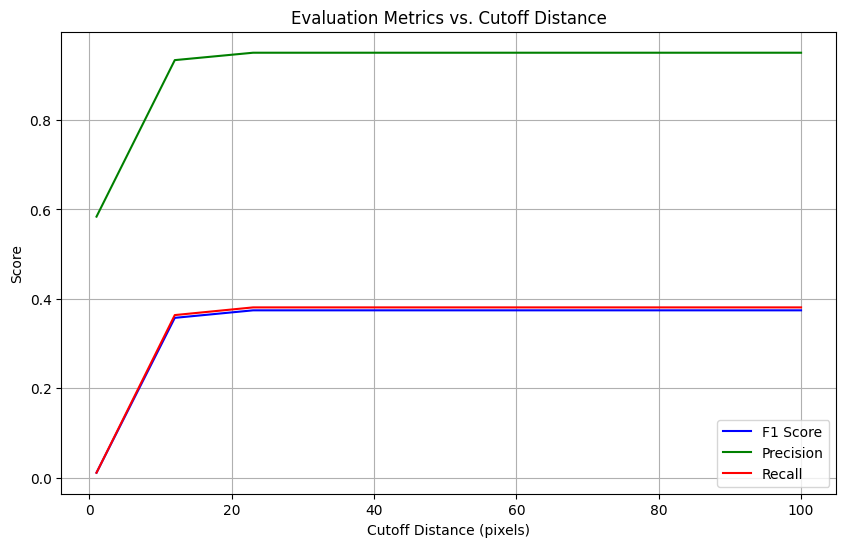

In [17]:
cutoff_distances = np.linspace(1, 100, 10)

all_stats = tuple(
    points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)
    for cutoff_distance in cutoff_distances
)

all_f1 = np.array([stat.f1 for stat in all_stats])
all_precision = np.array([stat.precision for stat in all_stats])
all_recall = np.array([stat.recall for stat in all_stats])

print(cutoff_distances)
print(all_f1.round(4))


plt.figure(figsize=(10, 6))
plt.plot(cutoff_distances, all_f1, label="F1 Score", color="blue")
plt.plot(cutoff_distances, all_precision, label="Precision", color="green")
plt.plot(cutoff_distances, all_recall, label="Recall", color="red")
plt.xlabel("Cutoff Distance (pixels)")
plt.ylabel("Score")
plt.title("Evaluation Metrics vs. Cutoff Distance")
plt.legend()
plt.grid()

In [18]:
# Create DataFrame with metrics, this makes it easier for further plotting
df_metrics = pd.DataFrame(
    {
        "cutoff_distance": cutoff_distances,
        "f1": all_f1,
        "precision": all_precision,
        "recall": all_recall,
    }
)

# Melt to get metric names in single column
df_metrics = df_metrics.melt(
    id_vars=["cutoff_distance"],
    value_vars=["f1", "precision", "recall"],
    var_name="metric",
    value_name="value",
)

In [ ]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Create 3 subplots for precision, recall, and f1
fig, axes = plt.subplots(1, 3, figsize=(12, 4), num=1, clear=True)

# Plot each metric using a loop with zip
metrics = [all_precision, all_recall, all_f1]
titles = ["Precision", "Recall", "F1 Score"]

colors = ["green", "red", "blue"]
for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(cutoff_distances, metric, "o-", linewidth=2, markersize=6, color=colors)
    ax.set_title(title)
    ax.set_xlabel("Cutoff Distance")
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    sns.despine()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined